# Mutual Fund Analytics - Exploratory Data Analysis

## 1. Project Overview

## 2. Import Libraries

## 3. Load Datasets

## 4. Data Quality Checks

## 5. NAV Trend Analysis

## 6. AUM Growth Analysis

## 7. SIP Inflow Trend Analysis

## 8. Category Inflow Heatmap

## 9. Investor Demographics Analysis

### 9.1 Age Distribution

### 9.2 Gender Distribution

### 9.3 SIP Amount by Age Group

## 10. Geographic Distribution

### 10.1 SIP Amount by State

### 10.2 T30 vs B30 Distribution

## 11. Folio Growth Analysis

## 12. NAV Return Correlation Analysis

## 13. Sector Allocation Analysis

## 14. Additional Insights

## 15. Key Findings (10 Insights)

## 16. Conclusion

In [30]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [31]:
# Load datasets

fund_master = pd.read_csv("../data/raw/Copy of 01_fund_master.csv")

nav_history = pd.read_csv(
    "../data/raw/Copy of 02_nav_history.csv",
    parse_dates=["date"]
)

aum = pd.read_csv(
    "../data/raw/Copy of 03_aum_by_fund_house.csv",
    parse_dates=["date"]
)

sip = pd.read_csv(
    "../data/raw/Copy of 04_monthly_sip_inflows.csv"
)

category_inflows = pd.read_csv(
    "../data/raw/Copy of 05_category_inflows.csv"
)

folio = pd.read_csv(
    "../data/raw/Copy of 06_industry_folio_count.csv"
)

scheme_perf = pd.read_csv(
    "../data/raw/Copy of 07_scheme_performance.csv"
)

investors = pd.read_csv(
    "../data/raw/Copy of 08_investor_transactions.csv",
    parse_dates=["transaction_date"]
)

portfolio = pd.read_csv(
    "../data/raw/Copy of 09_portfolio_holdings.csv"
)

benchmark = pd.read_csv(
    "../data/raw/Copy of 10_benchmark_indices.csv",
    parse_dates=["date"]
)

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [32]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category Inflows:", category_inflows.shape)
print("Folio:", folio.shape)
print("Scheme Performance:", scheme_perf.shape)
print("Investors:", investors.shape)
print("Portfolio Holdings:", portfolio.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category Inflows: (144, 3)
Folio: (21, 6)
Scheme Performance: (40, 19)
Investors: (32778, 13)
Portfolio Holdings: (322, 8)
Benchmark: (8050, 3)


In [33]:
# Missing values check

datasets = {
    "fund_master": fund_master,
    "nav_history": nav_history,
    "aum": aum,
    "sip": sip,
    "category_inflows": category_inflows,
    "folio": folio,
    "scheme_perf": scheme_perf,
    "investors": investors,
    "portfolio": portfolio,
    "benchmark": benchmark
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("-" * 50)
    print(df.isnull().sum())


FUND_MASTER
--------------------------------------------------
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

NAV_HISTORY
--------------------------------------------------
amfi_code    0
date         0
nav          0
dtype: int64

AUM
--------------------------------------------------
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

SIP
--------------------------------------------------
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

CATEGORY_I

In [34]:
# Merge NAV data with scheme names

nav_plot = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of All 40 Mutual Fund Schemes (2022–2026)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.08,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.06,
    annotation_text="2024 Market Correction",
    annotation_position="top right"
)

fig.update_layout(
    height=700,
    legend_title="Scheme Name",
    xaxis_title="Date",
    yaxis_title="NAV"
)

fig.write_image("../reports/nav_trend_analysis.png")

fig.show()

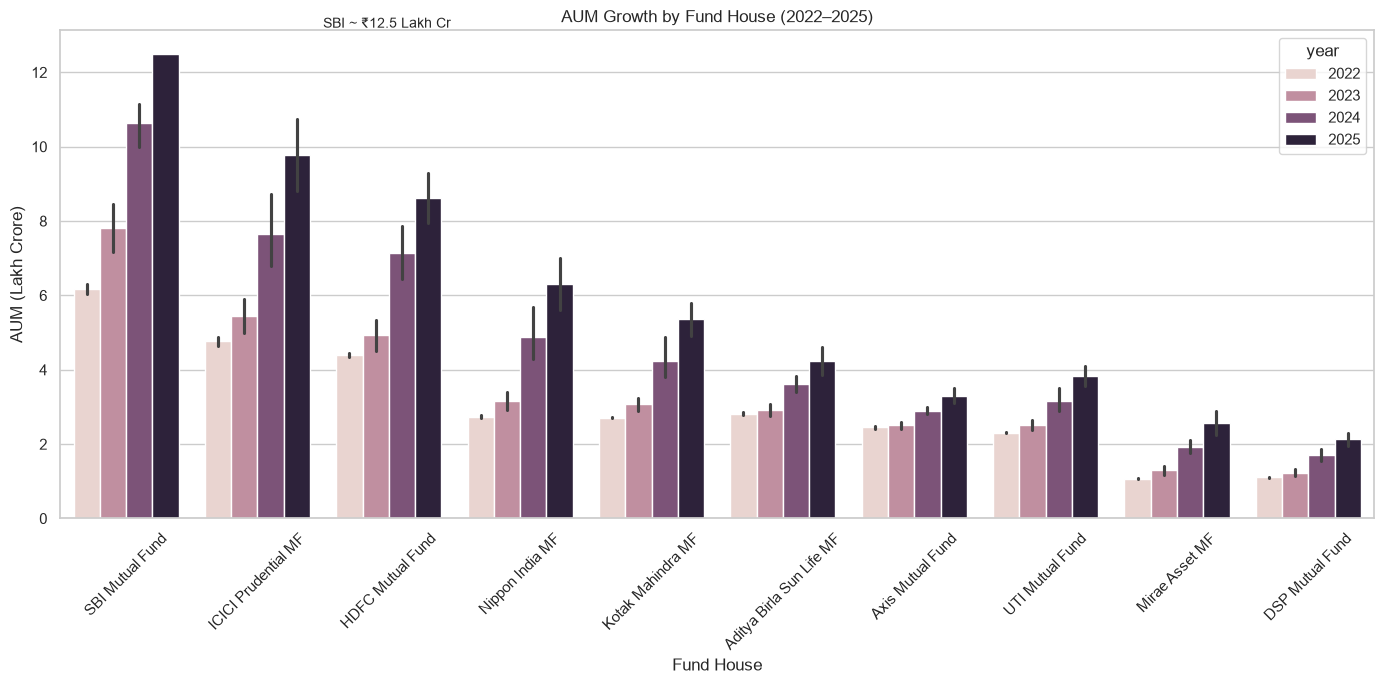

In [35]:
# AUM Growth Analysis

aum["year"] = pd.to_datetime(aum["date"]).dt.year

plt.figure(figsize=(14, 7))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=45)

# Highlight SBI dominance
plt.annotate(
    "SBI ~ ₹12.5 Lakh Cr",
    xy=(0, 12.5),
    xytext=(1.5, 13.2),
    fontsize=10,
    arrowprops=dict(arrowstyle="->", lw=1.5)
)


plt.tight_layout()

plt.savefig(
    "../reports/AUM_Growth_by_fund_house.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
# SIP Inflow Time Series

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (Jan 2022 - Dec 2025)"
)

# Highlight all-time high
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=str(max_row["month"]),
    y=max_row["sip_inflow_crore"],
    text=f"All-Time High<br>₹{max_row['sip_inflow_crore']:.0f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (Crore ₹)",
    height=600
)

fig.write_image("../reports/sip_inflow_trend.png")

fig.show()

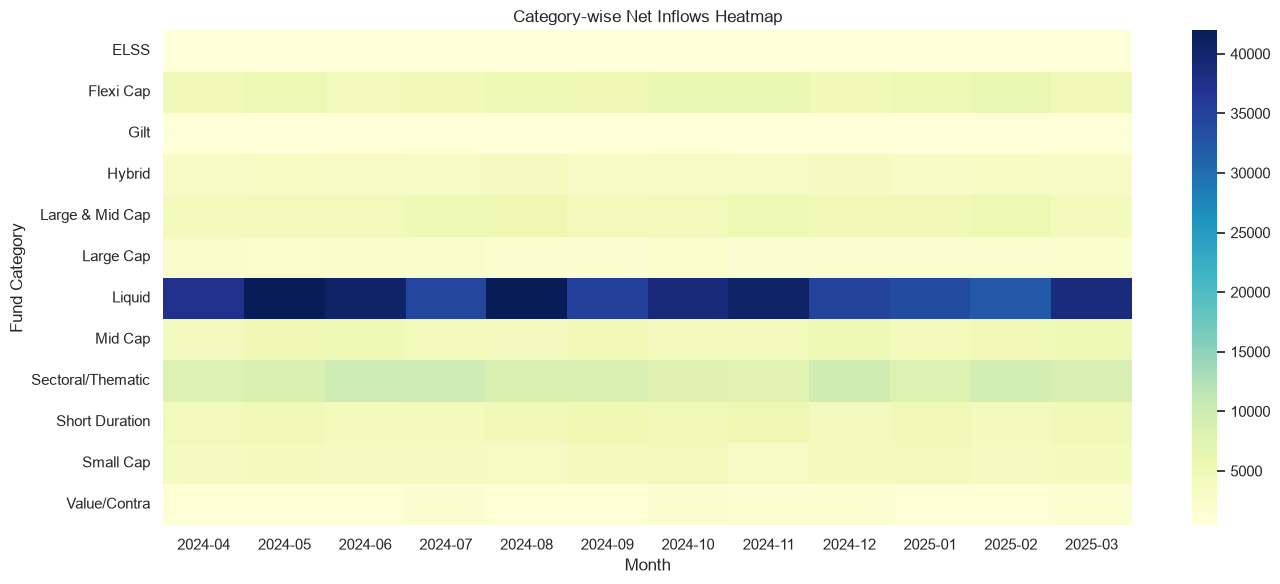

In [37]:
# Category Inflow Heatmap

heatmap_df = category_inflows.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_df,
    cmap="YlGnBu",
    annot=False
)

plt.title("Category-wise Net Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    "../reports/category-wise Net Inflows Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

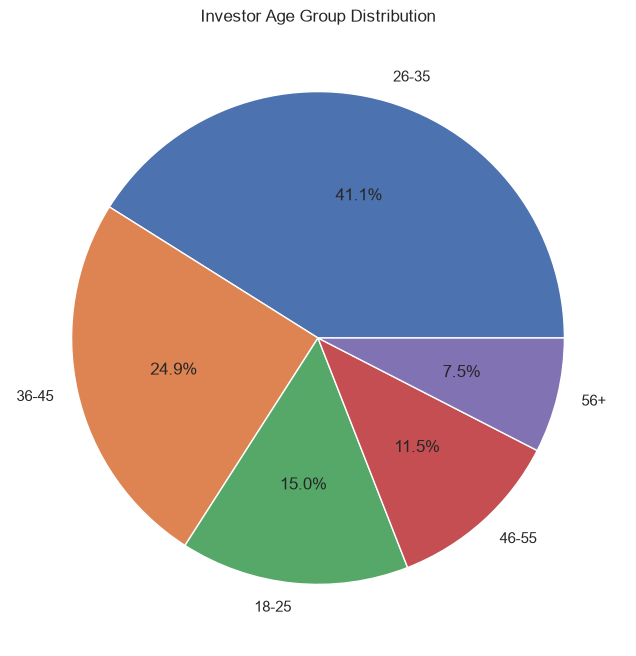

In [38]:
# Age Distribution

age_counts = investors["age_group"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/Investor Age Group Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

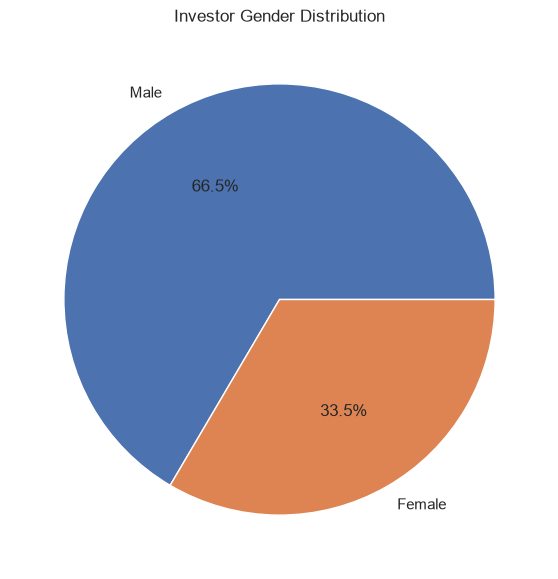

In [39]:
# Gender Distribution

gender_counts = investors["gender"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Gender Distribution")

plt.savefig(
    "../reports/Investor Gender Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

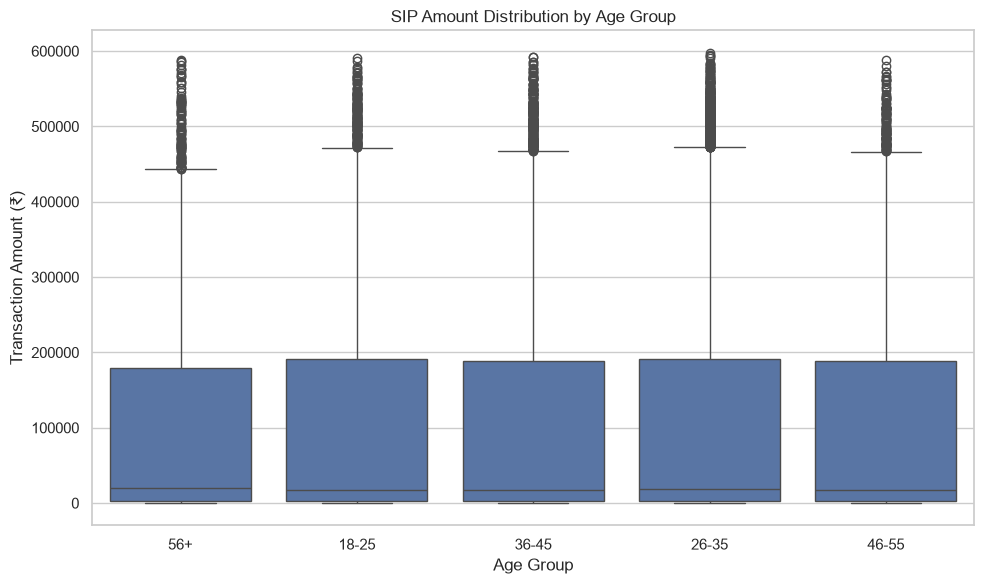

In [40]:
# SIP Amount Distribution by Age Group

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=investors,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Transaction Amount (₹)")

plt.tight_layout()

plt.savefig(
    "../reports/SIP Amount Distribution by Age Group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

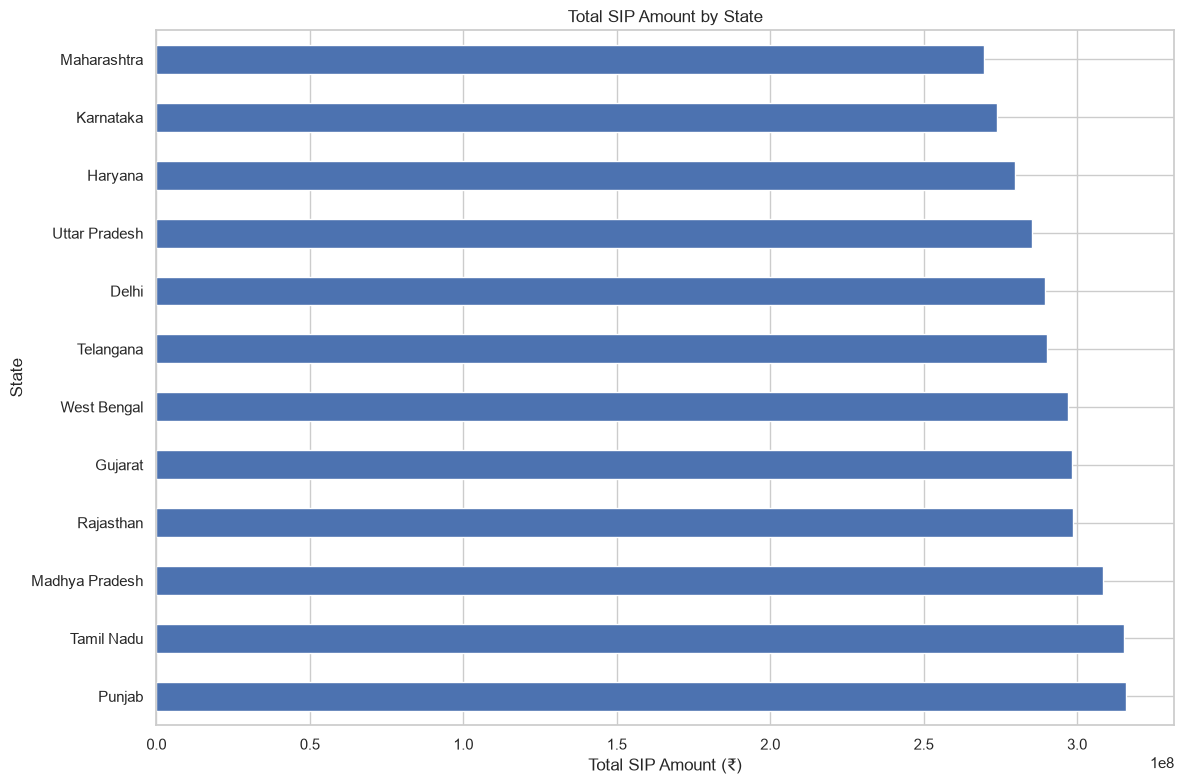

In [41]:
# SIP Amount by State

state_sip = (
    investors.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 8))

state_sip.plot(kind="barh")

plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/Total SIP Amount by State.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
investors["city_tier"].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

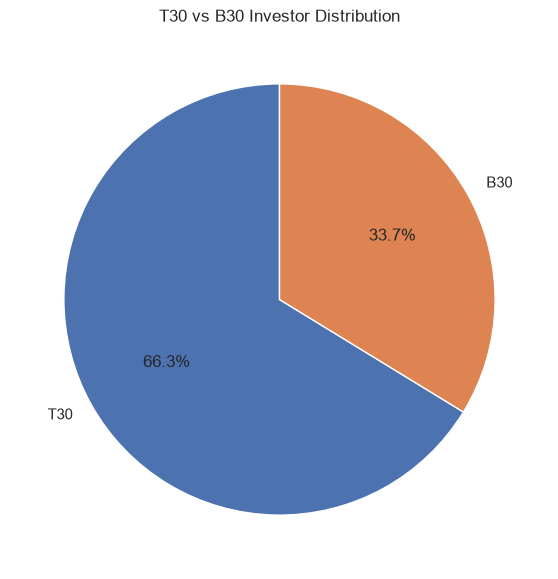

In [43]:
# T30 vs B30 Distribution

tier_counts = investors["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig(
    "../reports/T30 vs B30 Investor Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [45]:
folio.tail()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
16,2025-07,24.57,17.20,3.44,1.47,2.46
17,2025-08,24.89,17.42,3.48,1.49,2.49
18,2025-09,25.19,17.63,3.53,1.51,2.52
19,2025-10,25.60,17.92,3.58,1.54,2.56
20,2025-12,26.12,18.28,3.66,1.57,2.61


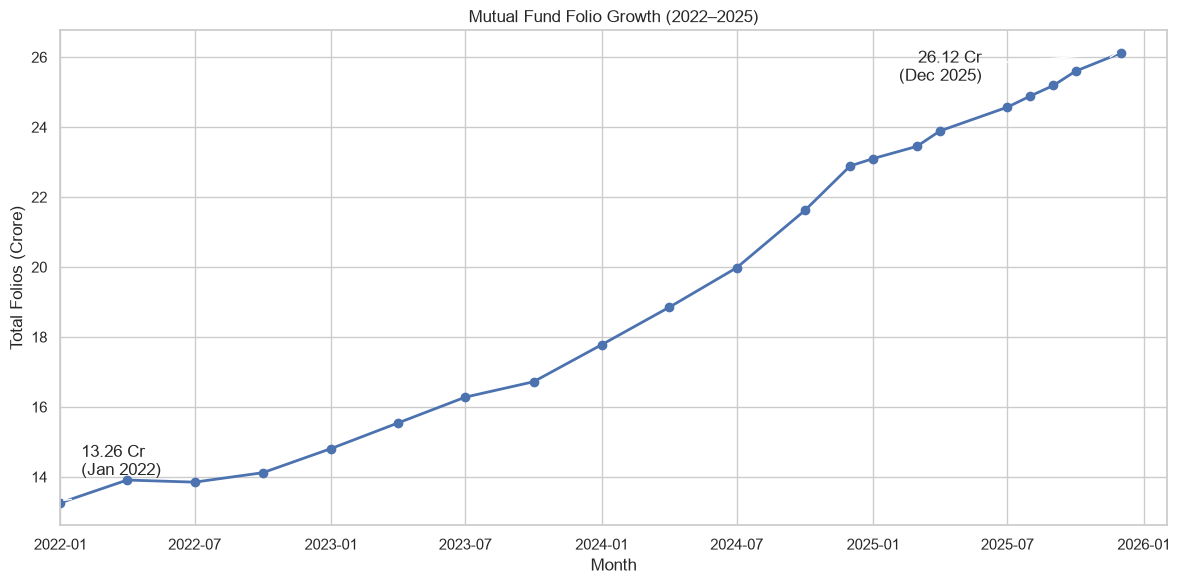

In [46]:
# Folio Growth Analysis

import matplotlib.pyplot as plt
import pandas as pd

folio_plot = folio.copy()

folio_plot["month"] = pd.to_datetime(folio_plot["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio_plot["month"],
    folio_plot["total_folios_crore"],
    marker="o",
    linewidth=2
)

# Start milestone
plt.annotate(
    "13.26 Cr\n(Jan 2022)",
    xy=(
        folio_plot.iloc[0]["month"],
        folio_plot.iloc[0]["total_folios_crore"]
    ),
    xytext=(15,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# End milestone
plt.annotate(
    "26.12 Cr\n(Dec 2025)",
    xy=(
        folio_plot.iloc[-1]["month"],
        folio_plot.iloc[-1]["total_folios_crore"]
    ),
    xytext=(-100, -20),
    textcoords="offset points",
    ha="right",
    arrowprops=dict(arrowstyle="->")
)


plt.title("Mutual Fund Folio Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.xlim(
    folio_plot["month"].min(),
    folio_plot["month"].max() + pd.DateOffset(months=2)
)

plt.tight_layout()

plt.savefig(
    "../reports/Mutual Fund Folio Growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

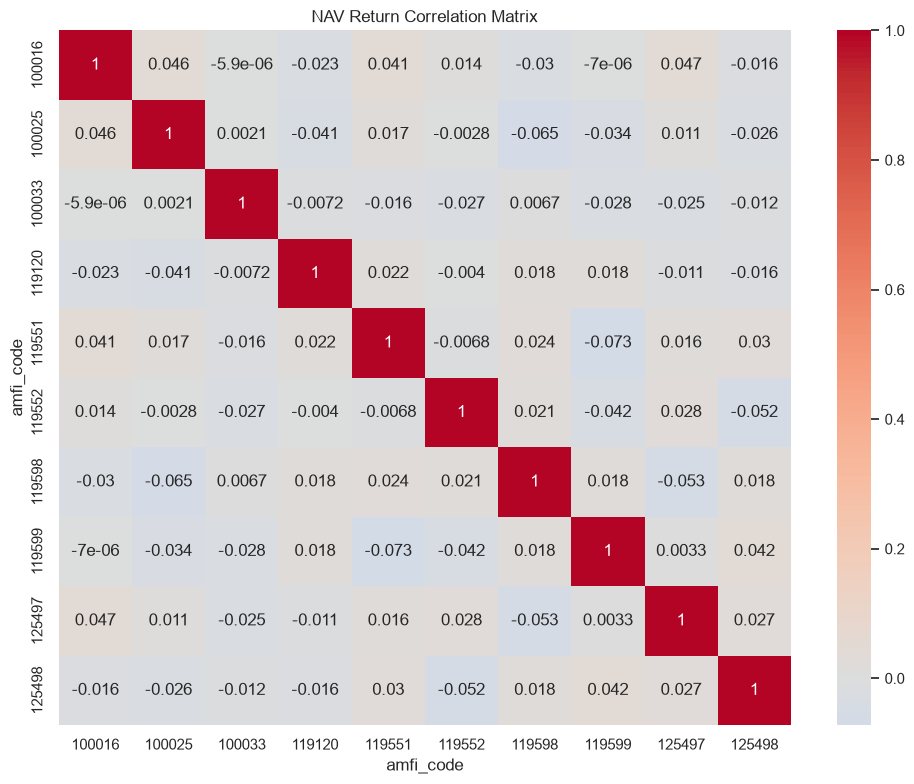

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select first 10 funds
selected_funds = nav_history['amfi_code'].unique()[:10]

nav_subset = nav_history[
    nav_history['amfi_code'].isin(selected_funds)
].copy()

# Calculate daily returns
nav_subset['daily_return'] = (
    nav_subset.groupby('amfi_code')['nav']
    .pct_change()
)

# Pivot table
returns_pivot = nav_subset.pivot_table(
    index='date',
    columns='amfi_code',
    values='daily_return'
)

# Correlation matrix
corr_matrix = returns_pivot.corr()

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('NAV Return Correlation Matrix')
plt.tight_layout()

plt.savefig(
    "../reports/NAV Return Correlation Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

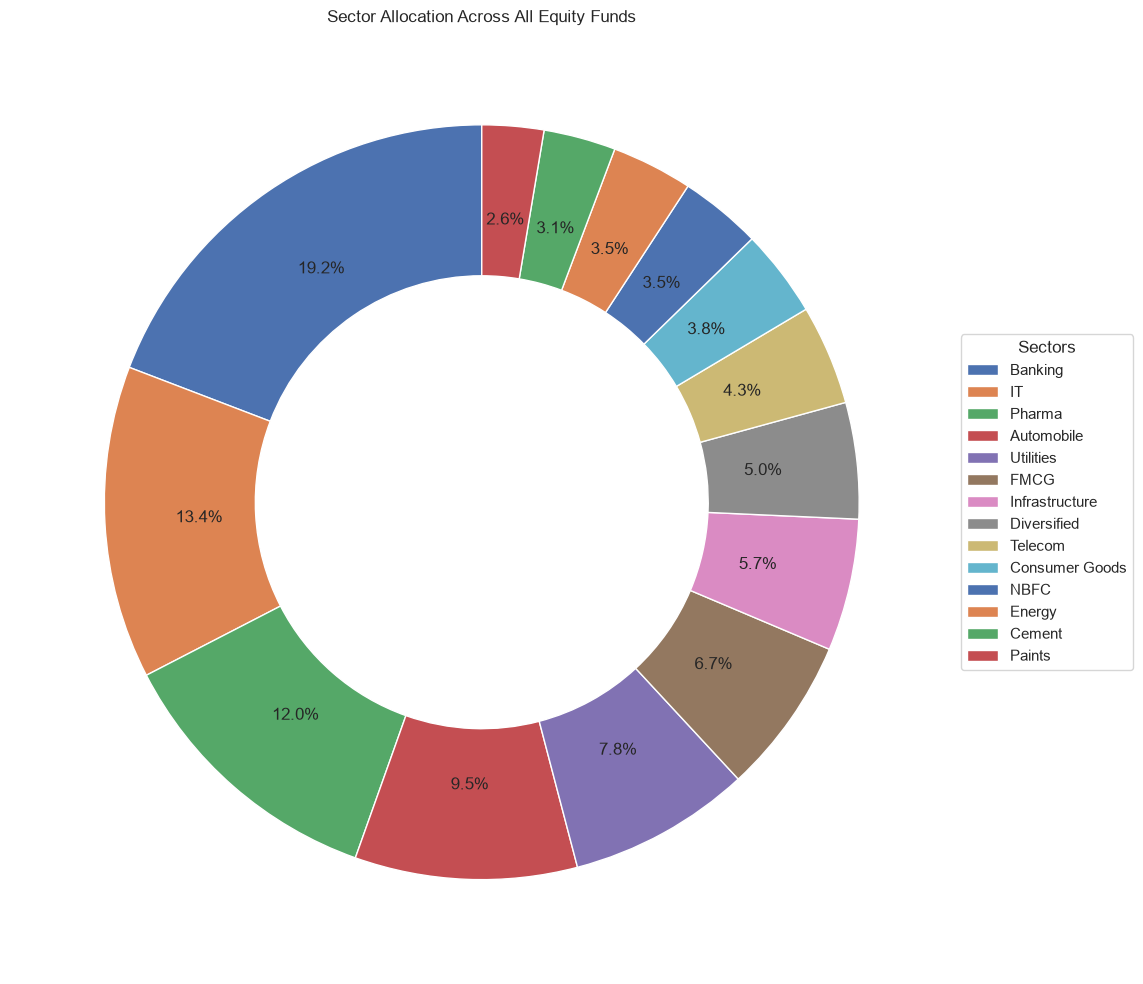

In [48]:
sector_alloc = (
    portfolio
    .groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12,10))

wedges, texts, autotexts = ax.pie(
    sector_alloc,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'width':0.4}
)

ax.legend(
    wedges,
    sector_alloc.index,
    title="Sectors",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Sector Allocation Across All Equity Funds")
plt.tight_layout()

plt.savefig(
    "../reports/Sector Allocation Across All Equity Funds.png",
    dpi=300,
    bbox_inches="tight"
)
            
plt.show()

In [49]:
scheme_perf.describe()

,amfi_code,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.00000,40.000000,40.000000
mean,120247.000000,14.376000,14.089000,14.516750,12.835500,1.253500,0.873250,1.361750,2.082500,14.962500,-19.200250,26091.60000,1.237000,4.250000
std,14534.998667,4.883023,4.617253,4.454021,4.740972,0.447412,0.224846,1.475805,2.203144,6.669282,8.819164,13809.11134,0.386584,0.742484
min,100016.000000,4.260000,5.140000,5.430000,3.960000,0.510000,0.220000,0.800000,1.030000,0.500000,-33.500000,979.00000,0.550000,3.000000
25%,118632.750000,11.735000,12.035000,12.340000,10.690000,0.887500,0.890000,0.865000,1.270000,14.000000,-25.062500,17400.50000,0.787500,4.000000
50%,119551.500000,14.620000,14.205000,14.185000,13.090000,1.205000,0.960000,0.925000,1.445000,14.000000,-20.600000,26713.00000,1.425000,4.000000
75%,120842.250000,16.392500,15.882500,17.585000,14.775000,1.700000,1.000000,0.985000,1.637500,19.000000,-14.255000,38125.00000,1.540000,5.000000
max,149324.000000,24.930000,23.390000,23.800000,22.160000,1.980000,1.040000,7.680000,10.370000,25.000000,-2.230000,49046.00000,1.640000,5.000000


## 15. Key Findings

1. Total folio count nearly doubled from 13.26 Cr in Jan 2022 to 26.12 Cr in Dec 2025.

2. SIP inflows reached an all-time high of ₹31,002 Cr in Dec 2025, indicating strong retail participation.

3. SBI Mutual Fund maintained the highest AUM among all fund houses throughout the analysis period.

4. NAVs across most schemes displayed a strong upward trend between 2022 and 2026.

5. The 2023 bull market period contributed significantly to NAV appreciation across schemes.

6. Market correction during 2024 resulted in temporary moderation in NAV growth.

7. Liquid funds consistently recorded the highest category-wise net inflows.

8. Investors aged 26–45 formed the largest contributor group in mutual fund transactions.

9. T30 cities accounted for approximately two-thirds of total investor participation.

10. Equity folios contributed the majority share of total folio growth across the industry.

## 16. Conclusion

The mutual fund industry demonstrated strong growth between 2022 and 2025 across AUM, SIP inflows, NAV performance, and folio counts. Increasing retail participation, sustained SIP investments, and growth in equity-oriented schemes indicate positive long-term investor confidence. Overall industry trends suggest continued expansion and deeper market penetration across India.

